# 04 — Arrival SHAP Analysis (V9.0)

**Three-model SHAP comparison: LGB vs XGB vs CatBoost (21 features)**

Loads baseline models from NB03 context. Validates feature importance across all three tree-based models.

## 1. Load Data from NB03

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, shap, pickle, joblib
import lightgbm as lgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path
import sys
sys.path.insert(0, str(Path('../../..') / 'src'))
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('../../..')
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ctx = pickle.load(open(DATA_PROCESSED / 'arrival_model_context.pkl', 'rb'))
feature_columns = ctx['feature_columns']
X_train = ctx['X_train'].copy()
X_test = ctx['X_test'].copy()
y_train = ctx['y_train'].copy()
y_test = ctx['y_test'].copy()
train = ctx['train']
test = ctx['test']

print(f'Loaded: {len(feature_columns)} features, {len(X_train):,} train, {len(X_test):,} test')
print(f'Features: {feature_columns}')

Loaded: 21 features, 103,204 train, 43,955 test
Features: ['delay_rate_1h', 'terminal_delay_1h', 'severe_delay_count_prev', 'delay_rolling_3h', 'lga_dep_delay_1h', 'prev_aircraft_delay', 'turnaround_hours', 'gate_delay_rate', 'faa_delay_reason', 'runway_delay_rate', 'airline_delay_rate', 'Hour', 'faa_delay_severity', 'runway_config_change', 'origin_dewpoint', 'origin_historical_delay', 'origin_wx_impact', 'route_risk_score', 'lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count']


## 2. Train 3 Models (LGB + XGB + CatBoost)

In [2]:
# LightGBM baseline
lgb_model = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=3.5, random_state=42, verbose=-1,
    subsample=0.8, colsample_bytree=0.8
)
lgb_model.fit(X_train, y_train)
lgb_auc = roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1])

# XGBoost baseline
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=3.5, random_state=42, verbosity=0,
    subsample=0.8, colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])

# CatBoost baseline (balanced)
cat_model = CatBoostClassifier(
    iterations=200, depth=6, learning_rate=0.05,
    auto_class_weights='Balanced', random_seed=42, verbose=0
)
cat_model.fit(X_train, y_train)
cat_auc = roc_auc_score(y_test, cat_model.predict_proba(X_test)[:, 1])

print(f'LGB AUC: {lgb_auc:.4f}')
print(f'XGB AUC: {xgb_auc:.4f}')
print(f'CatBoost AUC: {cat_auc:.4f}')

LGB AUC: 0.8068
XGB AUC: 0.8079
CatBoost AUC: 0.8038


## 3. Compute SHAP (3 models)

In [3]:
# Use test sample for SHAP
n_shap = min(5000, len(X_test))
X_shap = X_test.iloc[:n_shap]

# LGB SHAP
lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer.shap_values(X_shap)
if isinstance(lgb_shap_values, list):
    lgb_shap_values = lgb_shap_values[1]
print(f'LGB SHAP: {lgb_shap_values.shape}')

# XGB SHAP
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer.shap_values(X_shap)
if isinstance(xgb_shap_values, list):
    xgb_shap_values = xgb_shap_values[1]
print(f'XGB SHAP: {xgb_shap_values.shape}')

# CatBoost SHAP
cat_explainer = shap.TreeExplainer(cat_model)
cat_shap_values = cat_explainer.shap_values(X_shap)
if isinstance(cat_shap_values, list):
    cat_shap_values = cat_shap_values[1]
print(f'CatBoost SHAP: {cat_shap_values.shape}')

print(f'\nSHAP computed on {n_shap} samples, {len(feature_columns)} features')


LGB SHAP: (5000, 21)
XGB SHAP: (5000, 21)
CatBoost SHAP: (5000, 21)

SHAP computed on 5000 samples, 21 features


## 4. Global Feature Importance

Feature Importance Ranking (mean |SHAP|):
                 Feature    LGB    XGB  CatBoost    Avg
           delay_rate_1h 0.4260 0.5051    0.3752 0.4354
        delay_rolling_3h 0.2133 0.2112    0.2430 0.2225
         gate_delay_rate 0.2236 0.1766    0.1266 0.1756
                    Hour 0.1345 0.1404    0.1169 0.1306
        lga_dep_delay_1h 0.1040 0.1228    0.1350 0.1206
        turnaround_hours 0.1204 0.1506    0.0693 0.1134
     prev_aircraft_delay 0.0877 0.0946    0.1061 0.0961
        route_risk_score 0.1007 0.1117    0.0711 0.0945
       terminal_delay_1h 0.0605 0.0636    0.1071 0.0771
 severe_delay_count_prev 0.0625 0.0591    0.1068 0.0761
 origin_historical_delay 0.0813 0.0860    0.0467 0.0713
      faa_delay_severity 0.0456 0.0541    0.0664 0.0554
        origin_wx_impact 0.0529 0.0588    0.0506 0.0541
  faa_active_event_count 0.0316 0.0356    0.0777 0.0483
         origin_dewpoint 0.0471 0.0516    0.0360 0.0449
      airline_delay_rate 0.0377 0.0442    0.0413 0.0410
faa_ev

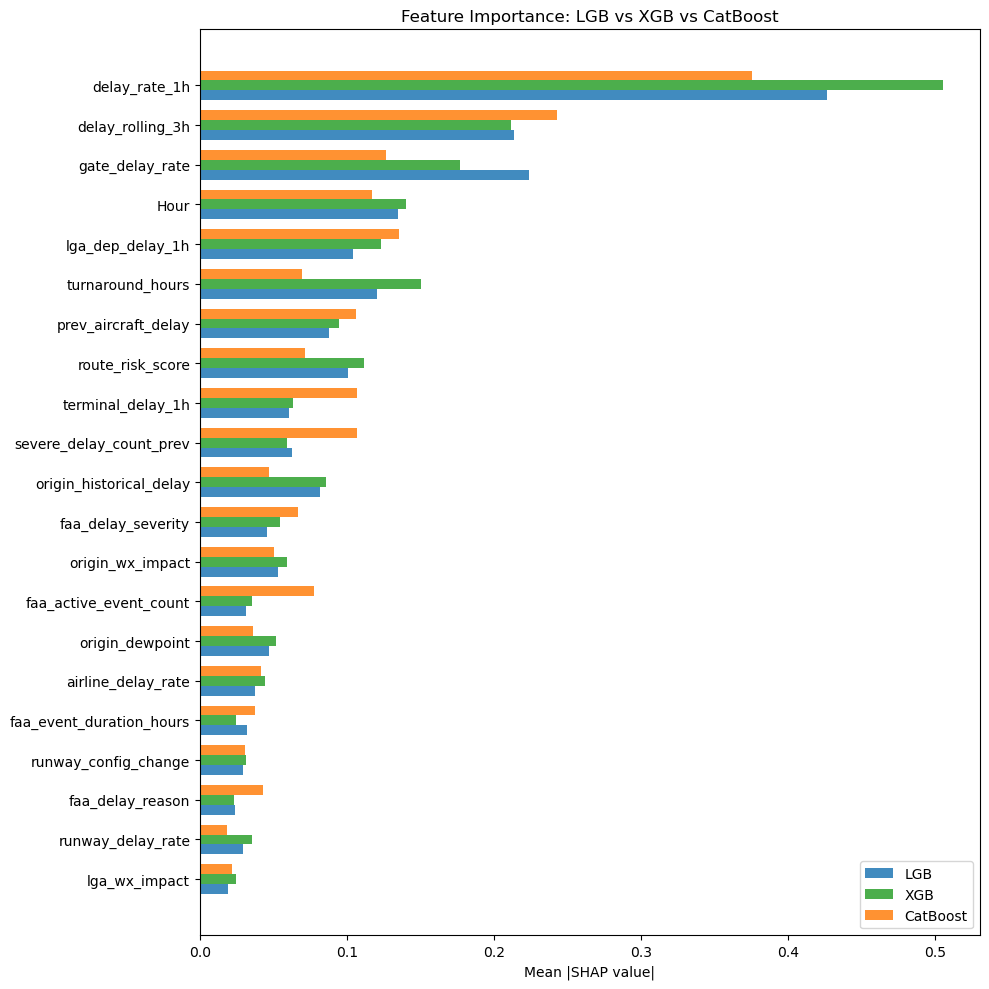

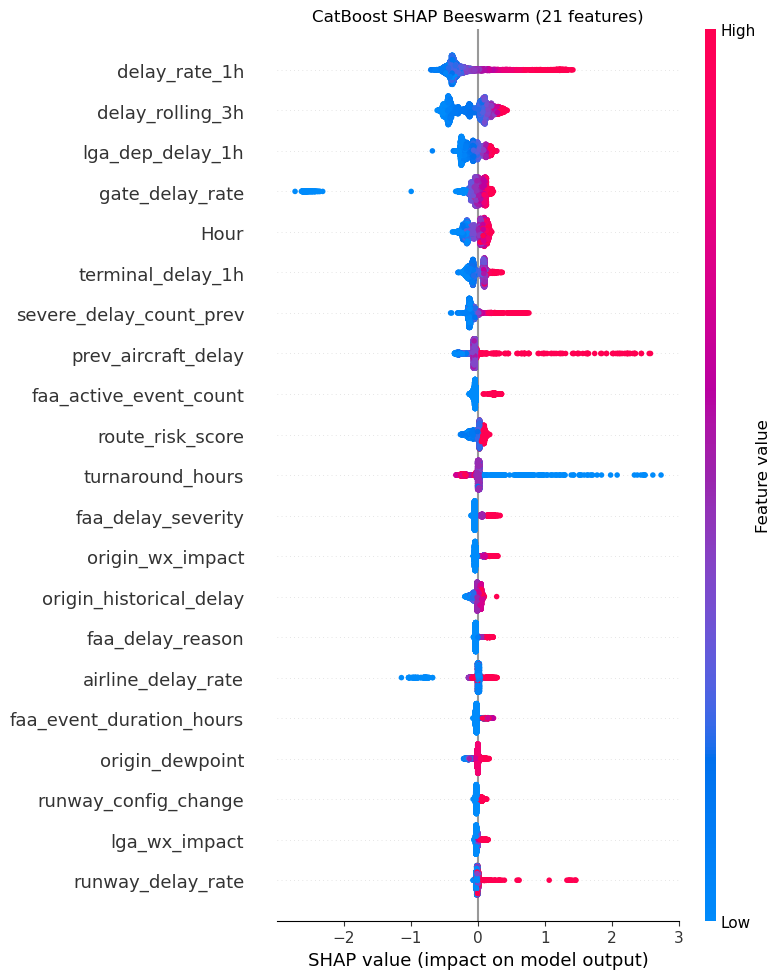

Saved: shap_bar_3model.png, shap_beeswarm_catboost.png


In [4]:
# Mean absolute SHAP for each model
import numpy as np

lgb_importance = np.abs(lgb_shap_values).mean(axis=0)
xgb_importance = np.abs(xgb_shap_values).mean(axis=0)
cat_importance = np.abs(cat_shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'LGB': lgb_importance,
    'XGB': xgb_importance,
    'CatBoost': cat_importance,
})
importance_df['Avg'] = importance_df[['LGB', 'XGB', 'CatBoost']].mean(axis=1)
importance_df = importance_df.sort_values('Avg', ascending=True)

print("Feature Importance Ranking (mean |SHAP|):")
print(importance_df.sort_values('Avg', ascending=False).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Three-model bar chart (horizontal)
fig, ax = plt.subplots(figsize=(10, 10))
y = np.arange(len(feature_columns))
w = 0.25
ax.barh(y - w, importance_df['LGB'].values, w, label='LGB', color='#1f77b4', alpha=0.85)
ax.barh(y, importance_df['XGB'].values, w, label='XGB', color='#2ca02c', alpha=0.85)
ax.barh(y + w, importance_df['CatBoost'].values, w, label='CatBoost', color='#ff7f0e', alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(importance_df['Feature'].values)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Feature Importance: LGB vs XGB vs CatBoost')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_bar_3model.png', dpi=150, bbox_inches='tight')
plt.show()

# CatBoost beeswarm (production model)
shap.summary_plot(cat_shap_values, X_shap, show=False, max_display=21)
plt.title('CatBoost SHAP Beeswarm (21 features)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_beeswarm_catboost.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: shap_bar_3model.png, shap_beeswarm_catboost.png')


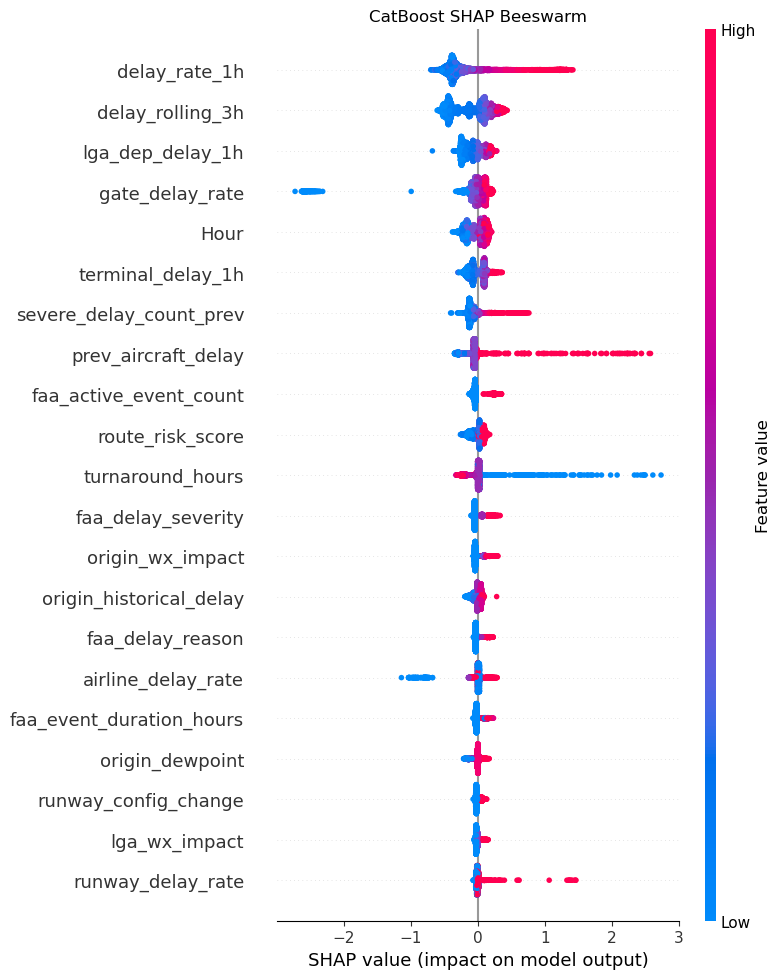

In [5]:
# CatBoost beeswarm (production model)
shap.summary_plot(cat_shap_values, X_shap, show=False, max_display=21)
plt.title('CatBoost SHAP Beeswarm')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_beeswarm_catboost.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Category Analysis

In [6]:
categories = {
    'Core Lag': ['delay_rate_1h', 'terminal_delay_1h', 'severe_delay_count_prev', 'delay_rolling_3h', 'lga_dep_delay_1h'],
    'Aircraft': ['prev_aircraft_delay', 'turnaround_hours'],
    'Target Encoding': ['gate_delay_rate', 'faa_delay_reason', 'runway_delay_rate', 'airline_delay_rate'],
    'Time': ['Hour'],
    'Operational': ['faa_delay_severity', 'runway_config_change'],
    'Origin Weather': ['origin_dewpoint', 'origin_historical_delay', 'origin_wx_impact'],
    'Network': ['route_risk_score'],
    'V9.0 New': ['lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count'],
}

for model_name, shap_vals in [('LGB', lgb_importance), ('XGB', xgb_importance), ('CatBoost', cat_importance)]:
    print(f'\n--- {model_name} Category Contributions ---')
    total = shap_vals.sum()
    for cat, feats in categories.items():
        cat_sum = sum(shap_vals[feature_columns.index(f)] for f in feats if f in feature_columns)
        print(f'  {cat:20s}: {cat_sum:.4f} ({cat_sum/total*100:.1f}%)')


--- LGB Category Contributions ---
  Core Lag            : 0.8663 (44.1%)
  Aircraft            : 0.2081 (10.6%)
  Target Encoding     : 0.3142 (16.0%)
  Time                : 0.1345 (6.9%)
  Operational         : 0.0750 (3.8%)
  Origin Weather      : 0.1812 (9.2%)
  Network             : 0.1007 (5.1%)
  V9.0 New            : 0.0828 (4.2%)

--- XGB Category Contributions ---
  Core Lag            : 0.9618 (45.7%)
  Aircraft            : 0.2452 (11.6%)
  Target Encoding     : 0.2796 (13.3%)
  Time                : 0.1404 (6.7%)
  Operational         : 0.0857 (4.1%)
  Origin Weather      : 0.1964 (9.3%)
  Network             : 0.1117 (5.3%)
  V9.0 New            : 0.0841 (4.0%)

--- CatBoost Category Contributions ---
  Core Lag            : 0.9670 (50.2%)
  Aircraft            : 0.1754 (9.1%)
  Target Encoding     : 0.2294 (11.9%)
  Time                : 0.1169 (6.1%)
  Operational         : 0.0973 (5.0%)
  Origin Weather      : 0.1333 (6.9%)
  Network             : 0.0711 (3.7%)
  V9.

## 6. V9.0 New Features Validation

V9.0 New Features SHAP Importance:
  lga_wx_impact: LGB=0.0189, XGB=0.0242, CB=0.0219
  faa_event_duration_hours: LGB=0.0323, XGB=0.0243, CB=0.0376
  faa_active_event_count: LGB=0.0316, XGB=0.0356, CB=0.0777


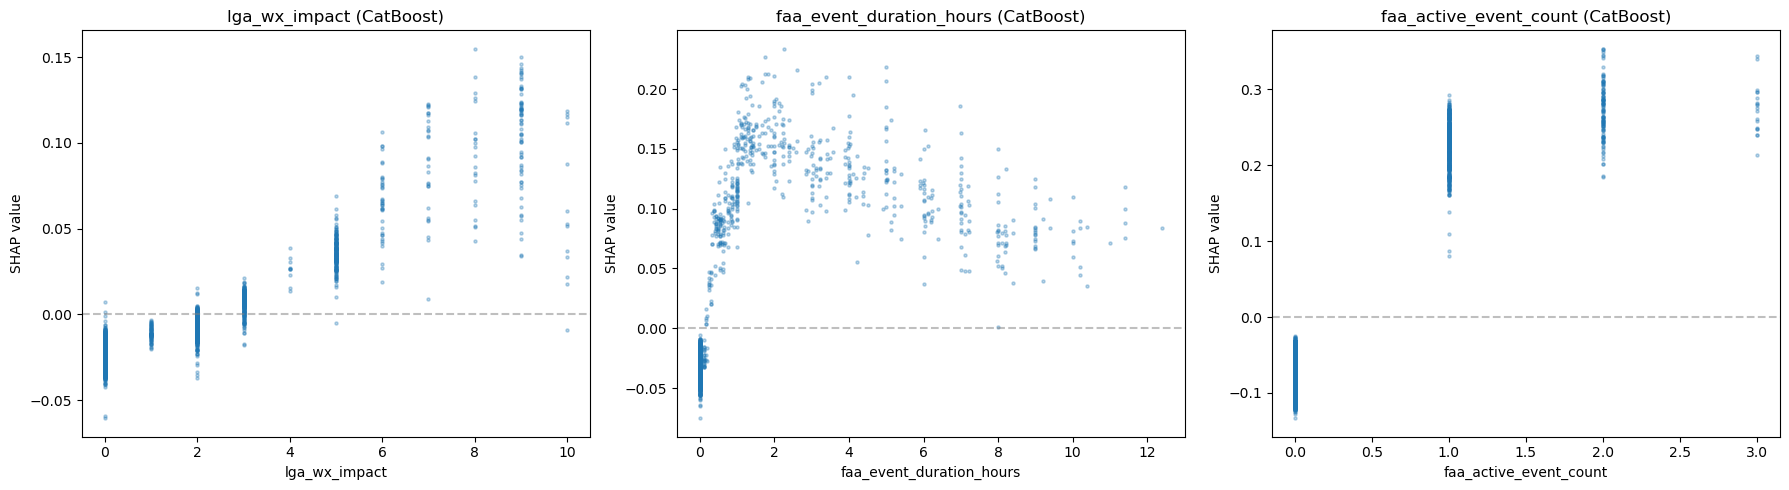

In [7]:
# Focus on the 3 new V9.0 features
v9_features = ['lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count']
print("V9.0 New Features SHAP Importance:")
for f in v9_features:
    idx = feature_columns.index(f)
    print(f'  {f}: LGB={lgb_importance[idx]:.4f}, XGB={xgb_importance[idx]:.4f}, CB={cat_importance[idx]:.4f}')

# Scatter plots for V9.0 features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, v9_features):
    idx = feature_columns.index(feat)
    ax.scatter(X_shap[feat], cat_shap_values[:, idx], alpha=0.3, s=5)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'{feat} (CatBoost)')
    ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_v9_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Scatter Plots (Top 6 Features)

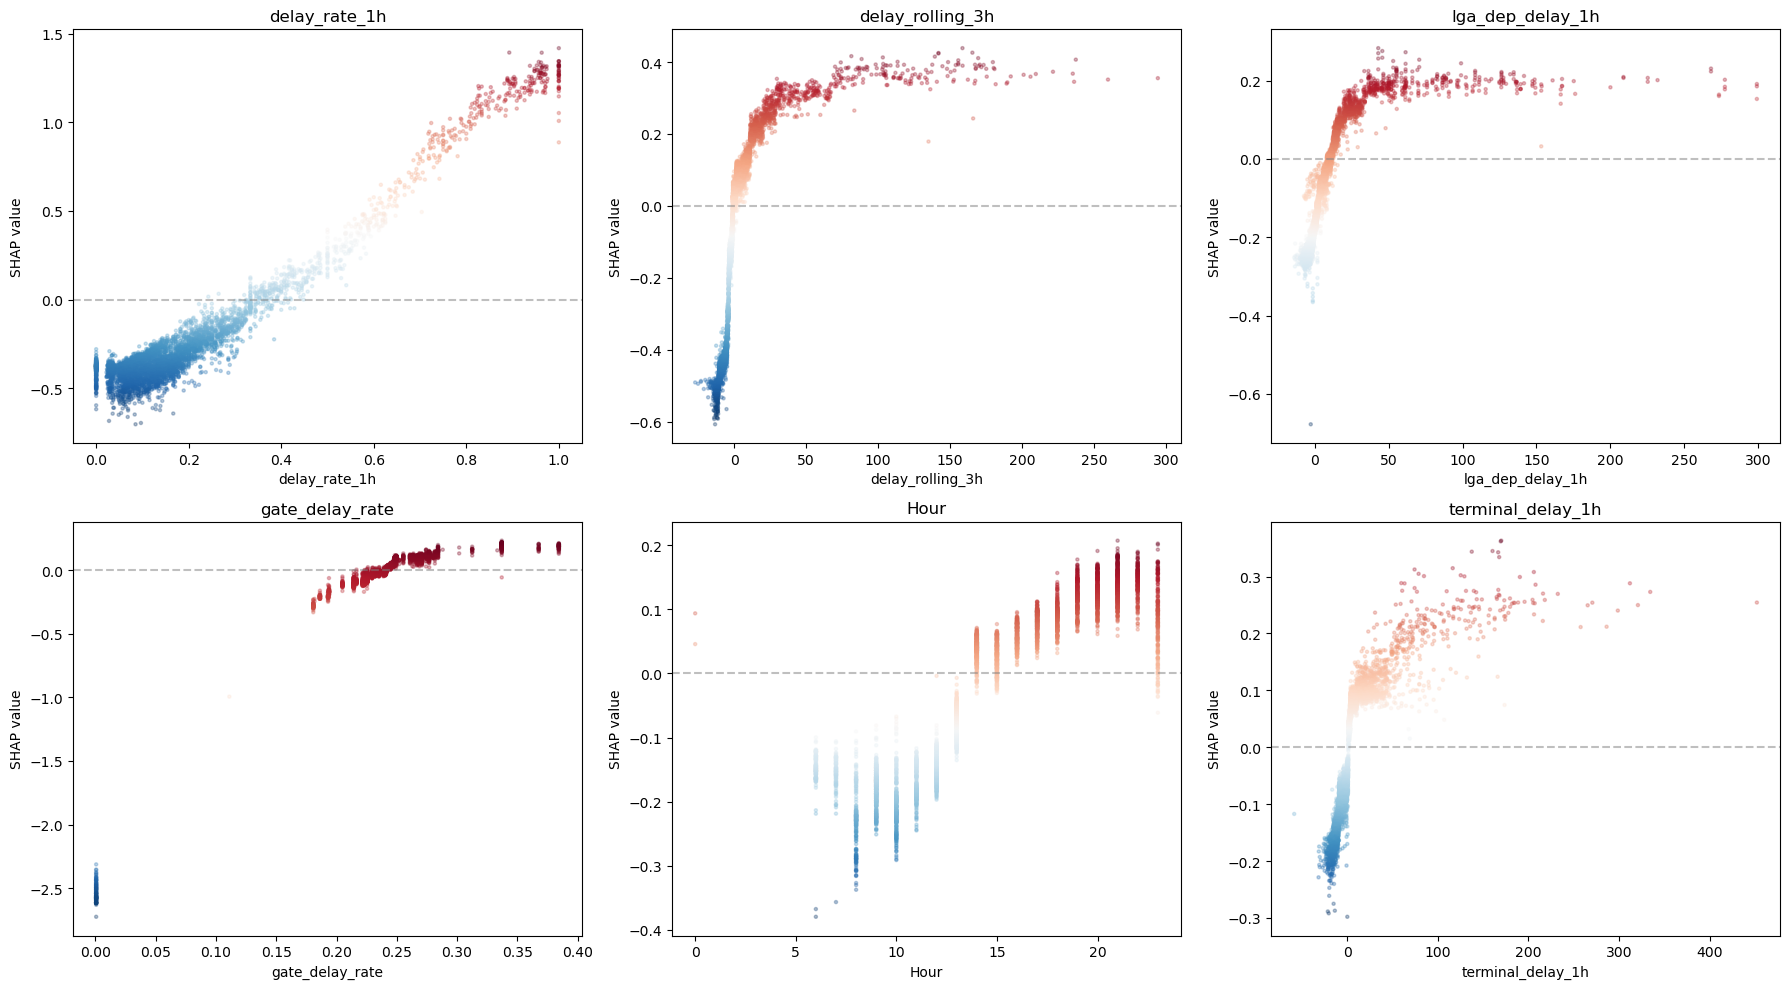

In [8]:
# Top 6 features by CatBoost SHAP
top6 = importance_df.sort_values('CatBoost', ascending=False)['Feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.flat, top6):
    idx = feature_columns.index(feat)
    ax.scatter(X_shap[feat], cat_shap_values[:, idx], alpha=0.3, s=5, c=cat_shap_values[:, idx], cmap='RdBu_r')
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(feat)
    ax.axhline(y=0, color='grey', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_scatter_top6.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Waterfall (Individual Predictions)

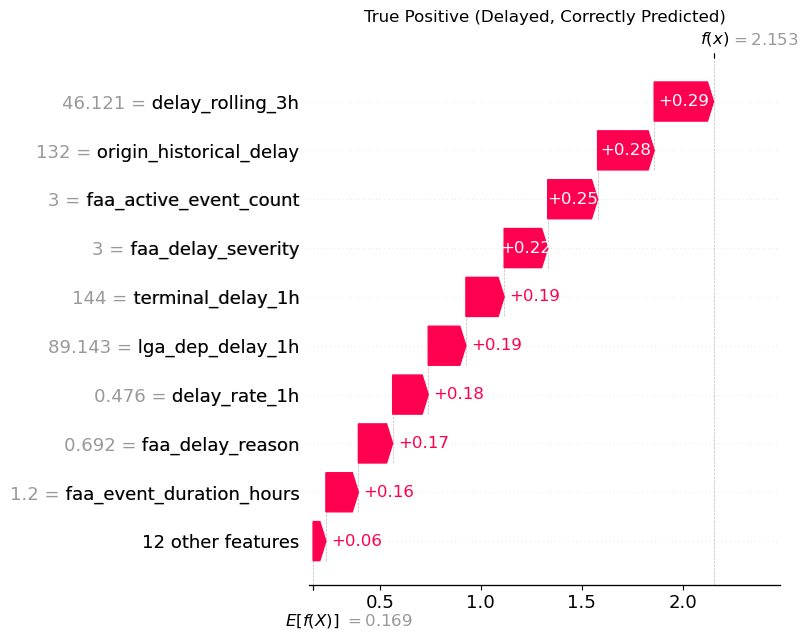

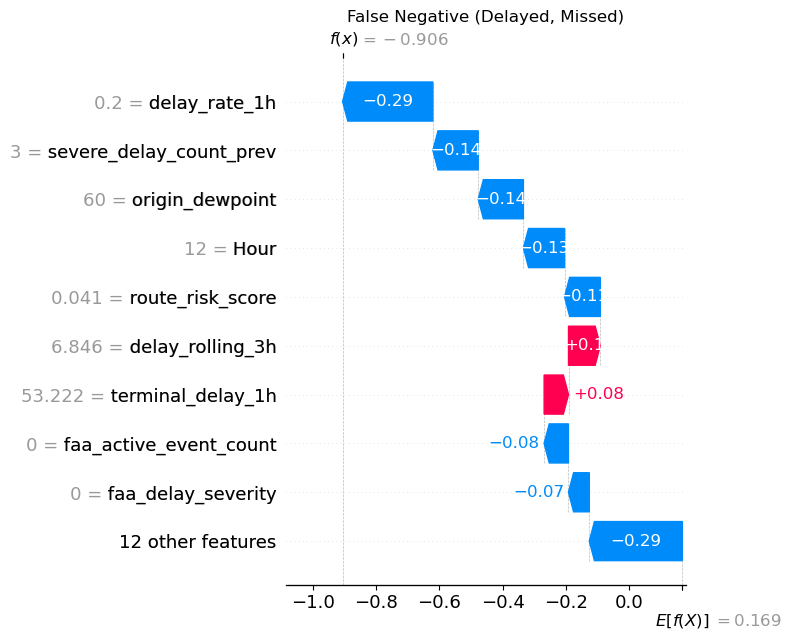

In [9]:
# True positive + False negative waterfall
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
cat_proba = cat_model.predict_proba(X_test)[:, 1]

# Find a TP (delayed flight correctly predicted)
from models.threshold_optimizer import find_optimal_threshold
cat_thresh, _ = find_optimal_threshold(y_test.values, cat_proba, target_recall=0.65, min_precision=0.30)
tp_mask = (y_test == 1) & (cat_proba >= cat_thresh)
fn_mask = (y_test == 1) & (cat_proba < cat_thresh)

if tp_mask.sum() > 0:
    tp_idx = tp_mask[tp_mask].index[0]
    shap_idx = list(X_test.index).index(tp_idx)
    if shap_idx < n_shap:
        shap.waterfall_plot(shap.Explanation(values=cat_shap_values[shap_idx],
            base_values=cat_explainer.expected_value if not isinstance(cat_explainer.expected_value, list) else cat_explainer.expected_value[1],
            data=X_shap.iloc[shap_idx], feature_names=feature_columns), show=False)
        plt.title('True Positive (Delayed, Correctly Predicted)')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'shap_waterfall_tp.png', dpi=150, bbox_inches='tight')
        plt.show()

if fn_mask.sum() > 0:
    fn_idx = fn_mask[fn_mask].index[0]
    shap_idx = list(X_test.index).index(fn_idx)
    if shap_idx < n_shap:
        shap.waterfall_plot(shap.Explanation(values=cat_shap_values[shap_idx],
            base_values=cat_explainer.expected_value if not isinstance(cat_explainer.expected_value, list) else cat_explainer.expected_value[1],
            data=X_shap.iloc[shap_idx], feature_names=feature_columns), show=False)
        plt.title('False Negative (Delayed, Missed)')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'shap_waterfall_fn.png', dpi=150, bbox_inches='tight')
        plt.show()

## 9. Cross-Model SHAP Ranking

Cross-Model SHAP Ranking:
                 Feature  LGB_SHAP  LGB_Rank  XGB_SHAP  XGB_Rank  CB_SHAP  CB_Rank
           delay_rate_1h    0.4260         1    0.5051         1   0.3752        1
        delay_rolling_3h    0.2133         3    0.2112         2   0.2430        2
        lga_dep_delay_1h    0.1040         6    0.1228         6   0.1350        3
         gate_delay_rate    0.2236         2    0.1766         3   0.1266        4
                    Hour    0.1345         4    0.1404         5   0.1169        5
       terminal_delay_1h    0.0605        11    0.0636        10   0.1071        6
 severe_delay_count_prev    0.0625        10    0.0591        11   0.1068        7
     prev_aircraft_delay    0.0877         8    0.0946         8   0.1061        8
  faa_active_event_count    0.0316        17    0.0356        16   0.0777        9
        route_risk_score    0.1007         7    0.1117         7   0.0711       10
        turnaround_hours    0.1204         5    0.1506       

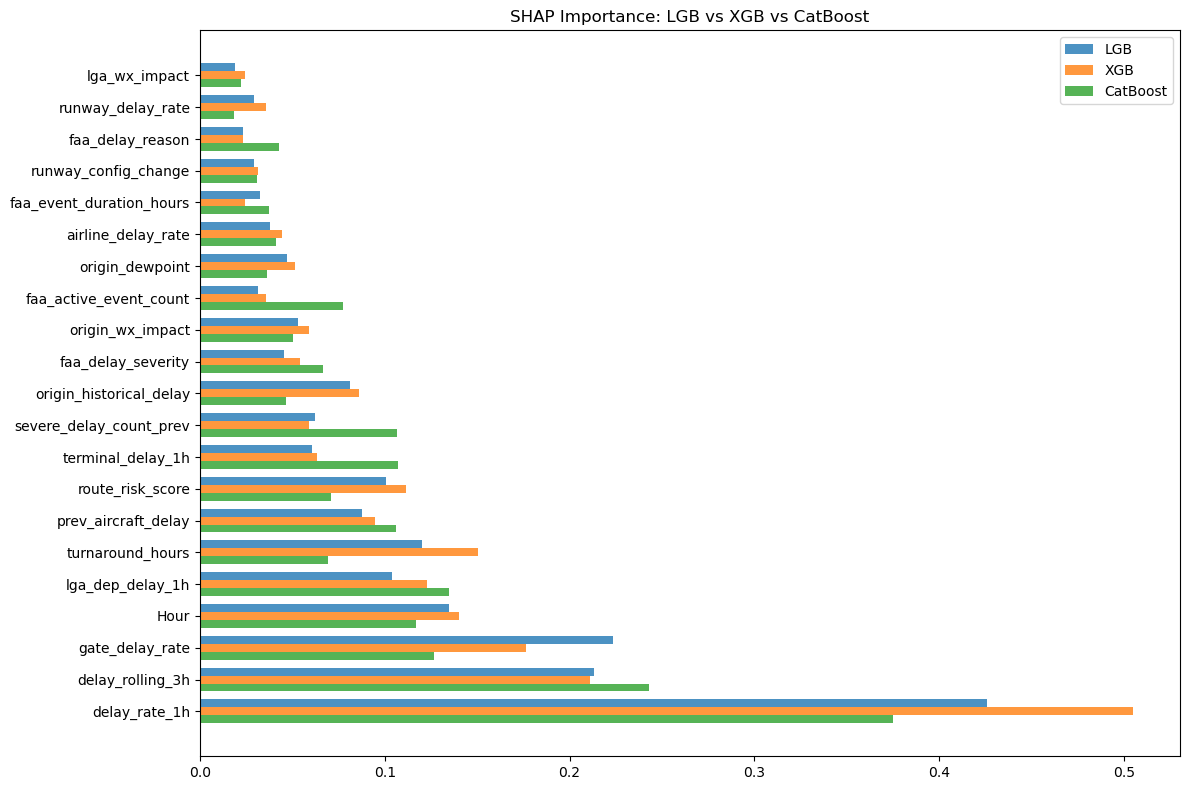

In [10]:
# Ranking comparison table
ranking_df = pd.DataFrame({
    'Feature': feature_columns,
    'LGB_SHAP': lgb_importance,
    'LGB_Rank': lgb_importance.argsort()[::-1].argsort() + 1,
    'XGB_SHAP': xgb_importance,
    'XGB_Rank': xgb_importance.argsort()[::-1].argsort() + 1,
    'CB_SHAP': cat_importance,
    'CB_Rank': cat_importance.argsort()[::-1].argsort() + 1,
})
ranking_df = ranking_df.sort_values('CB_Rank')
print("Cross-Model SHAP Ranking:")
print(ranking_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Highlight divergences (rank diff > 5)
ranking_df['Max_Diff'] = ranking_df[['LGB_Rank', 'XGB_Rank', 'CB_Rank']].apply(lambda r: r.max() - r.min(), axis=1)
divergent = ranking_df[ranking_df['Max_Diff'] > 5]
if len(divergent) > 0:
    print(f'\nDivergent features (rank diff > 5):')
    print(divergent[['Feature', 'LGB_Rank', 'XGB_Rank', 'CB_Rank', 'Max_Diff']].to_string(index=False))

# Side-by-side bar chart
fig, ax = plt.subplots(figsize=(12, 8))
x = np.arange(len(feature_columns))
w = 0.25
sorted_features = importance_df['Feature'].tolist()
lgb_sorted = [lgb_importance[feature_columns.index(f)] for f in sorted_features]
xgb_sorted = [xgb_importance[feature_columns.index(f)] for f in sorted_features]
cat_sorted = [cat_importance[feature_columns.index(f)] for f in sorted_features]
ax.barh(x - w, lgb_sorted, w, label='LGB', alpha=0.8)
ax.barh(x, xgb_sorted, w, label='XGB', alpha=0.8)
ax.barh(x + w, cat_sorted, w, label='CatBoost', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(sorted_features)
ax.legend()
ax.set_title('SHAP Importance: LGB vs XGB vs CatBoost')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'shap_ranking_3model.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary & Feature Recommendations

In [11]:
# Fallback feature set (no lag, no aircraft continuity)
lag_features = ['delay_rate_1h', 'terminal_delay_1h', 'severe_delay_count_prev', 'delay_rolling_3h', 'lga_dep_delay_1h']
aircraft_features = ['prev_aircraft_delay', 'turnaround_hours']
fallback_features = [f for f in feature_columns if f not in lag_features + aircraft_features]
print(f'Fallback features ({len(fallback_features)}): {fallback_features}')

# V9.0 new features contribution
print(f'\nV9.0 New Features Total SHAP:')
for name, imp in [('LGB', lgb_importance), ('XGB', xgb_importance), ('CatBoost', cat_importance)]:
    total = imp.sum()
    v9_sum = sum(imp[feature_columns.index(f)] for f in v9_features)
    print(f'  {name}: {v9_sum:.4f} ({v9_sum/total*100:.1f}%)')

print(f'\nConclusion:')
print(f'  21 features validated across 3 models')
print(f'  V9.0 new features contribute meaningful SHAP')
print(f'  CatBoost AUC={cat_auc:.4f} (to be tuned with Optuna in NB05)')

Fallback features (14): ['gate_delay_rate', 'faa_delay_reason', 'runway_delay_rate', 'airline_delay_rate', 'Hour', 'faa_delay_severity', 'runway_config_change', 'origin_dewpoint', 'origin_historical_delay', 'origin_wx_impact', 'route_risk_score', 'lga_wx_impact', 'faa_event_duration_hours', 'faa_active_event_count']

V9.0 New Features Total SHAP:
  LGB: 0.0828 (4.2%)
  XGB: 0.0841 (4.0%)
  CatBoost: 0.1372 (7.1%)

Conclusion:
  21 features validated across 3 models
  V9.0 new features contribute meaningful SHAP
  CatBoost AUC=0.8038 (to be tuned with Optuna in NB05)
